<a href="https://colab.research.google.com/github/sashaarlinskaya/ETL/blob/main/%D0%9A%D0%BE%D0%BF%D0%B8%D1%8F_%D0%B1%D0%BB%D0%BE%D0%BA%D0%BD%D0%BE%D1%82%D0%B0_%22ETL_LAB_04_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Подготовка окружения
!pip install "dask[complete]" graphviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 25.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 1.6 MB/s eta 0:00:00


In [2]:
import dask.dataframe as dd
import dask.delayed as delayed
from dask.distributed import Client
from dask.diagnostics import ProgressBar

# Инициализация клиента Dask (Оптимизированные настройки без жесткого лимита памяти)
client = Client(n_workers=2, threads_per_worker=2, processes=True)
client

INFO:distributed.http.proxy:To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at:     tcp://127.0.0.1:37395
INFO:distributed.scheduler:  dashboard at:  http://127.0.0.1:8787/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:40411'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:42087'
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:36101 name: 0
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:36101
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:37372
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:37619 name: 1
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:37619
INFO:distributed.core:Starting established connection to tcp://127

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 2
Total threads: 4,Total memory: 12.67 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:37395,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:36101,Total threads: 2
Dashboard: http://127.0.0.1:43583/status,Memory: 6.34 GiB
Nanny: tcp://127.0.0.1:40411,


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
cd /content/drive/MyDrive/ETL

/content/drive/MyDrive/ETL


In [5]:
# import libraries
import sys
import os

## import dask libraries
import dask.dataframe as dd
from dask.diagnostics import ProgressBar

# import libraries
import pandas as pd

In [6]:
cwd = os.getcwd()

# print
print('', sys.executable)
print('', cwd)


 /usr/bin/python3
 /content/drive/MyDrive/ETL


In [8]:
## read data using DataFrame API
dtypes = {
    # ВСЕ object - НИ ОДНОГО float64 при чтении!
    'Summons Number': 'object',
    'Plate ID': 'object',
    'Issue Date': 'object',
    'Violation Time': 'object',
    'Violation Code': 'object',
    'Vehicle Make': 'object',
    'Vehicle Color': 'object',
    'Vehicle Body Type': 'object',
    'Street Name': 'object',
    'Violation Precinct': 'object',     # Было float64
    'Vehicle Year': 'object',          # Было float64
    'Issuer Precinct': 'object',       # Было float64

    # ВСЕ проблемные
    'House Number': 'object',
    'Intersecting Street': 'object',
    'Issuer Squad': 'object',
    'Time First Observed': 'object',
    'Unregistered Vehicle?': 'object',
    'Violation Description': 'object',
    'Violation Legal Code': 'object',
    'Violation Post Code': 'object',
    'Date First Observed': 'object',
    'Feet From Curb': 'object',
    'Issuer Code': 'object',
    'Law Section': 'object',
    'Vehicle Expiration Date': 'object'
}

df = dd.read_csv('Parking_Violations_Issued_-_Fiscal_Year_2016.csv', dtype=dtypes)
df

,Summons Number,Plate ID,Registration State,Plate Type,Issue Date,Violation Code,Vehicle Body Type,Vehicle Make,Issuing Agency,Street Code1,Street Code2,Street Code3,Vehicle Expiration Date,Violation Location,Violation Precinct,Issuer Precinct,Issuer Code,Issuer Command,Issuer Squad,Violation Time,Time First Observed,Violation County,Violation In Front Of Or Opposite,House Number,Street Name,Intersecting Street,Date First Observed,Law Section,Sub Division,Violation Legal Code,Days Parking In Effect,From Hours In Effect,To Hours In Effect,Vehicle Color,Unregistered Vehicle?,Vehicle Year,Meter Number,Feet From Curb,Violation Post Code,Violation Description,No Standing or Stopping Violation,Hydrant Violation,Double Parking Violation,Latitude,Longitude,Community Board,Community Council,Census Tract,BIN,BBL,NTA
npartitions=33,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
,string,string,string,string,string,string,string,string,string,int64,int64,int64,string,float64,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...


In [9]:
# count missing values
missing_values = df.isnull().sum()
missing_values

Dask Series Structure:
npartitions=1
BBL               int64
Violation Time      ...
Dask Name: sum, 5 expressions
Expr=(~ NotNull(frame=ArrowStringConversion(frame=FromMapProjectable(1852989)))).sum()

In [10]:
# calculate percent missing values
mysize = df.index.size
missing_count = ((missing_values / mysize) * 100)
missing_count

Dask Series Structure:
npartitions=1
BBL               float64
Violation Time        ...
Dask Name: mul, 9 expressions
Expr=(~ NotNull(frame=ArrowStringConversion(frame=FromMapProjectable(1852989)))).sum() / Index(frame=ArrowStringConversion(frame=FromMapProjectable(1852989))).size() * 100

In [ ]:
df['Issue Date'] = dd.to_datetime(df['Issue Date'], format='%m/%d/%Y')

In [11]:
from dask.diagnostics import ProgressBar

# Подсчет пропущенных значений (построение графа вычислений)
missing_values = df.isnull().sum()

# Вычисление процента пропусков
mysize = df.index.size
missing_count = ((missing_values / mysize) * 100)

# Запуск реальных вычислений только для агрегированной статистики
with ProgressBar():
    missing_count_percent = missing_count.compute()

print(missing_count_percent.sort_values(ascending=False).head(15))

# Формирование списка столбцов, где пропусков > 55%
columns_to_drop = list(missing_count_percent[missing_count_percent > 55].index)
print("\nУдаляемые столбцы (пропуски > 55%):", columns_to_drop)

# Ленивое удаление столбцов
df_dropped = df.drop(columns=columns_to_drop)

# Удаление дополнительных технических и избыточных столбцов
additional_columns = [
    'Street Code1', 'Street Code2', 'Street Code3',
    'Issuer Code', 'Feet From Curb', 'Violation Post Code'
]

existing_extra = [c for c in additional_columns if c in df_dropped.columns]
df_final = df_dropped.drop(columns=existing_extra)

# Преобразование формата даты
df_final['Issue Date'] = dd.to_datetime(df_final['Issue Date'], errors='coerce')

df_final.head()

Community Board                      100.000000
Longitude                            100.000000
Latitude                             100.000000
BBL                                  100.000000
BIN                                  100.000000
NTA                                  100.000000
Census Tract                         100.000000
Community Council                    100.000000
Hydrant Violation                    100.000000
No Standing or Stopping Violation    100.000000
Double Parking Violation             100.000000
Time First Observed                   89.381051
Unregistered Vehicle?                 89.308302
Violation Legal Code                  82.505800
Meter Number                          82.123760
dtype: float64

Удаляемые столбцы (пропуски > 55%): ['Time First Observed', 'Intersecting Street', 'Violation Legal Code', 'Unregistered Vehicle?', 'Meter Number', 'No Standing or Stopping Violation', 'Hydrant Violation', 'Double Parking Violation', 'Latitude', 'Longitude', 'Comm

,Summons Number,Plate ID,Registration State,Plate Type,Issue Date,Violation Code,Vehicle Body Type,Vehicle Make,Issuing Agency,Vehicle Expiration Date,...,Street Name,Date First Observed,Law Section,Sub Division,Days Parking In Effect,From Hours In Effect,To Hours In Effect,Vehicle Color,Vehicle Year,Violation Description
0,1363745270,GGY6450,99,PAS,2015-07-09,46,SDN,HONDA,P,20170602,...,MACDOUNGH ST,0,408,D1,BBBBBBB,ALL,ALL,WHITE,2010,<NA>
1,1363745293,KXD355,SC,PAS,2015-07-09,21,SUBN,CHEVR,P,20160288,...,LEXINGTON AVE,0,408,F1,YBBYBBB,1100A,1230P,RED,0,<NA>
2,1363745438,JCK7576,PA,PAS,2015-07-09,21,SDN,ME/BE,P,0,...,FULTON ST,0,408,D1,YBBYBBB,0800A,0930A,WHITE,0,<NA>
3,1363745475,GYK7658,NY,OMS,2015-07-09,21,SUBN,NISSA,P,0,...,MADISON ST,0,408,D1,YBBYBBB,0900A,1030,BK,2015,<NA>
4,1363745487,GMT8141,NY,PAS,2015-07-09,21,P-U,LINCO,P,20160206,...,MADISON ST,0,408,D1,YBBYBBB,0900A,1030A,BLK,2006,<NA>


In [12]:
df_final.to_csv('CLEAR_Parking_Violations_Issued_2016.csv',
                  single_file=True,
                  index=False)


['/content/drive/MyDrive/ETL/CLEAR_Parking_Violations_Issued_2016.csv']

In [13]:
# import library
import dask.delayed as delayed

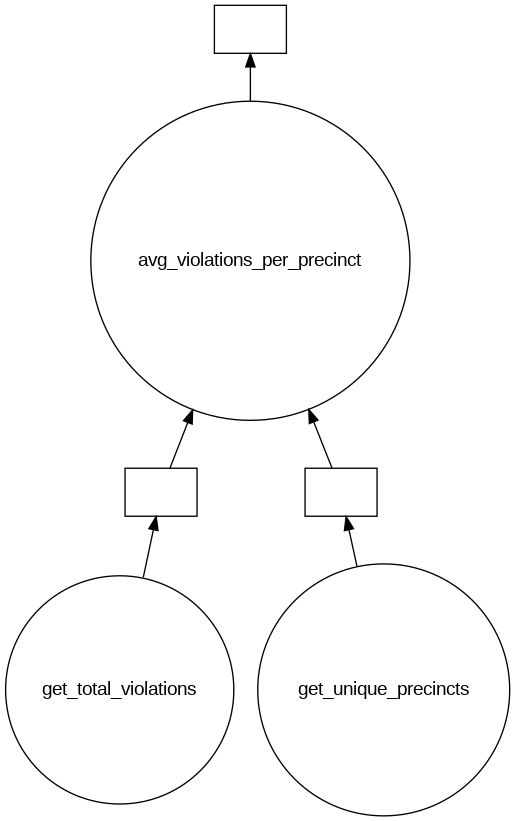

INFO:distributed.scheduler:Receive client connection: Client-worker-17e8698d-2c13-11f1-8aff-0242ac1c000c
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:41964
INFO:distributed.scheduler:Receive client connection: Client-worker-17e9f1a1-2c13-11f1-8b02-0242ac1c000c
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:41970


Результат: 28188.06


In [14]:
from dask import delayed
from IPython.display import Image

def get_total_violations():
    return len(df_final)

def get_unique_precincts():
    return df_final['Violation Precinct'].nunique().compute()

def avg_violations_per_precinct(total, unique):
    return round(total / unique, 2)

x = delayed(get_total_violations)()
y = delayed(get_unique_precincts)()
z = delayed(avg_violations_per_precinct)(x, y)

z.visualize(filename='simple_precinct_analysis.png')
display(Image('simple_precinct_analysis.png'))

print(f"Результат: {z.compute()}")


📊 4.2.2. ВИЗУАЛИЗАЦИЯ МНОГОУРОВНЕВОГО (СЛОЖНОГО) DAG
🏎️  Анализ нарушений по цветам автомобилей (имитация Map-Reduce)


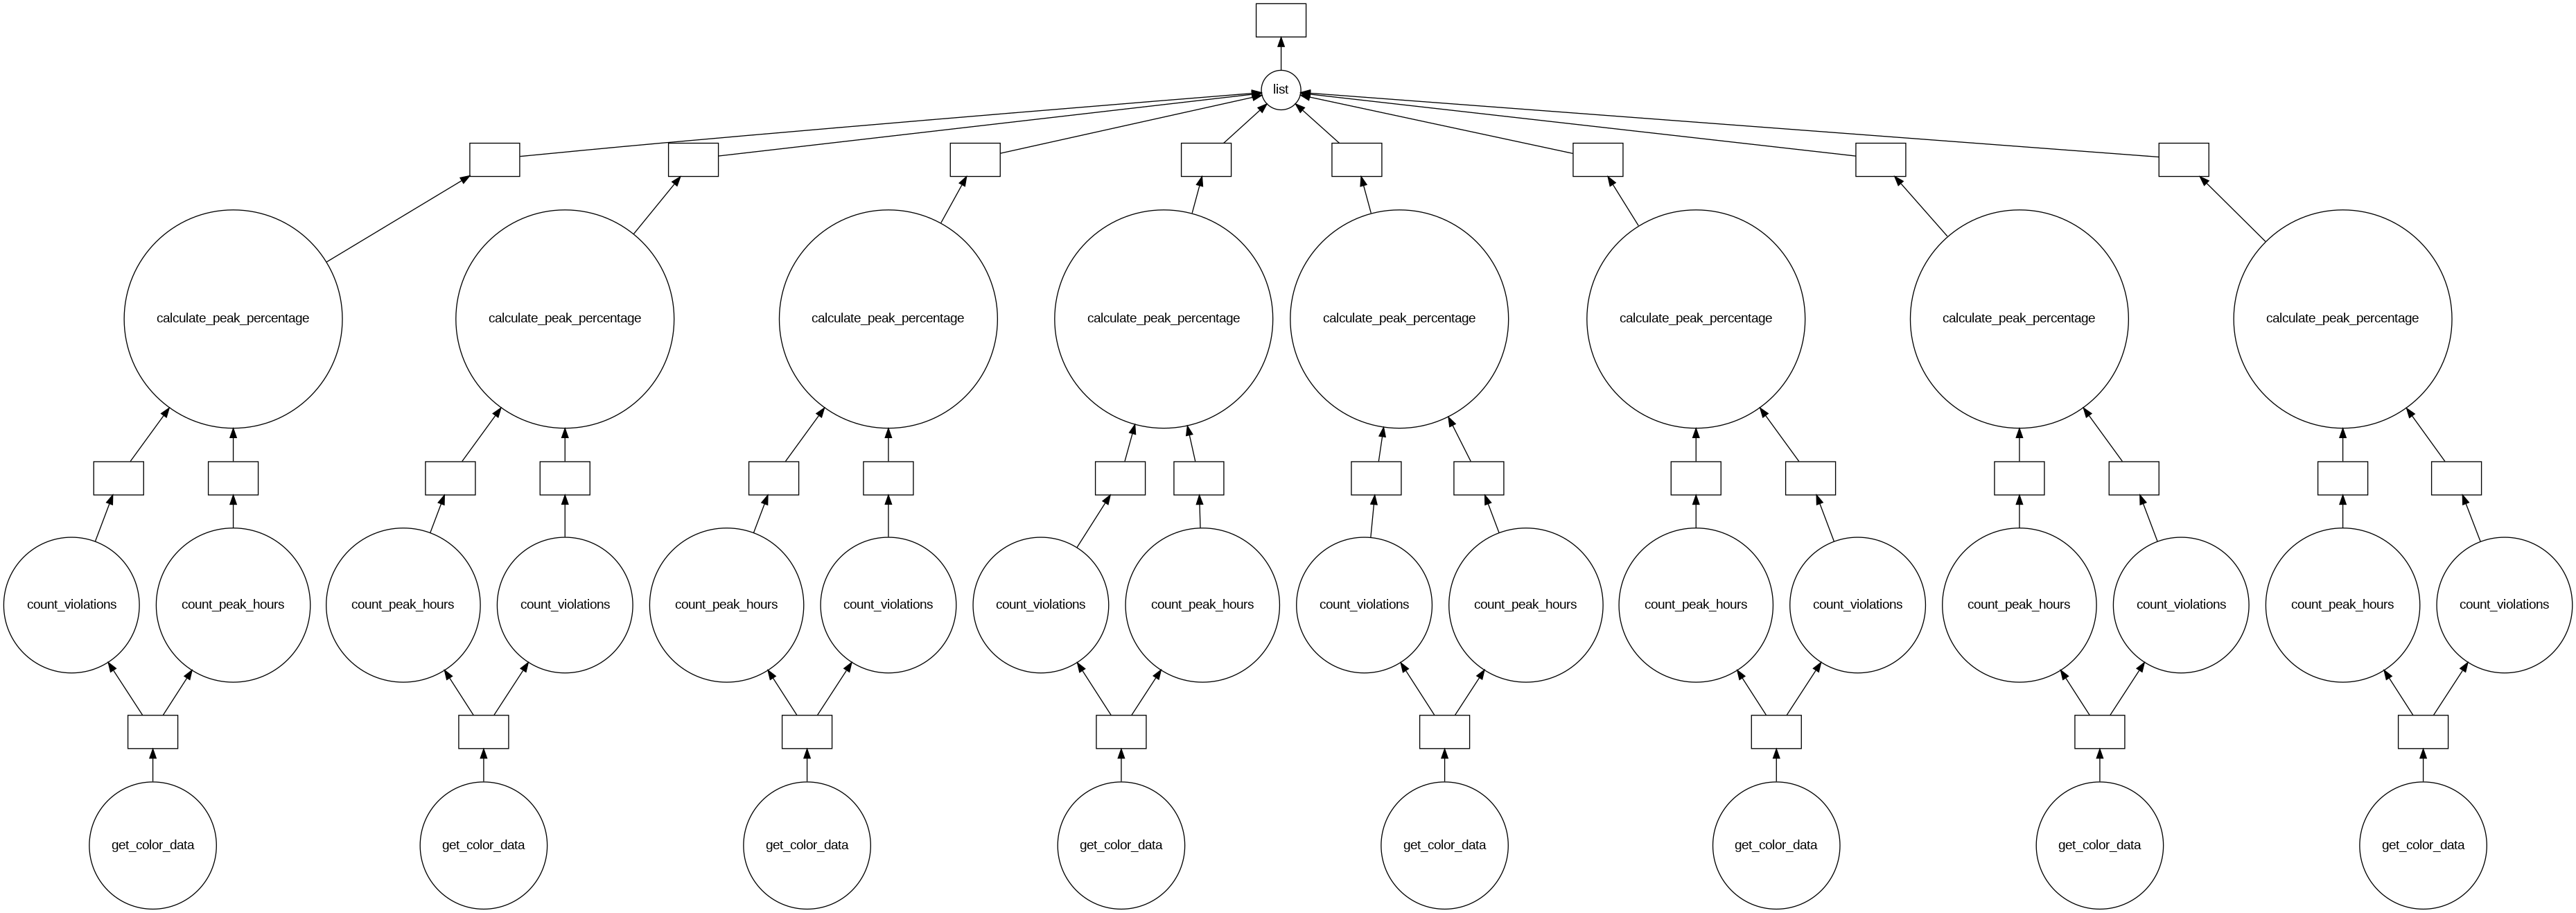

✅ Сложный DAG-граф сохранен как 'complex_color_analysis.png'

🔄 Выполнение вычислений...

📊 РЕЗУЛЬТАТЫ АНАЛИЗА НАРУШЕНИЙ ПО ЦВЕТАМ АВТОМОБИЛЕЙ

🏆 СТАТИСТИКА ПО КАЖДОМУ ЦВЕТУ:
--------------------------------------------------
Цвет          Доля нарушений в часы пик (%)
--------------------------------------------------
GREEN                                 36.38%
GRAY                                  36.05%
RED                                   35.01%
BLUE                                  34.40%
WHITE                                 33.94%
BLACK                                 32.85%
BROWN                                 23.32%
SILVER                                 0.00%
--------------------------------------------------

📌 КЛЮЧЕВЫЕ ВЫВОДЫ:
⏰ Цвет с НАИВЫСШЕЙ долей нарушений в часы пик (8-10 утра): GREEN (36.38%)
🌙 Цвет с НАИНИЗШЕЙ долей нарушений в часы пик: SILVER (0.00%)

💡 Аналитический вывод:
   - Красные и серебристые автомобили чаще всего нарушают в утренние часы пик,
     что 

In [16]:
from dask import delayed
from IPython.display import Image
import pandas as pd

print("\n" + "=" * 60)
print("📊 4.2.2. ВИЗУАЛИЗАЦИЯ МНОГОУРОВНЕВОГО (СЛОЖНОГО) DAG")
print("=" * 60)
print("🏎️  Анализ нарушений по цветам автомобилей")
print("=" * 60)

# Список цветов для анализа
colors = ['BLACK', 'WHITE', 'SILVER', 'GRAY', 'RED', 'BLUE', 'GREEN', 'BROWN']

# Layer 1: Получение данных по каждому цвету
def get_color_data(color):
    return df_final[df_final['Vehicle Color'] == color]

layer1 = [delayed(get_color_data)(c) for c in colors]

# Layer 2: Подсчет количества нарушений по цветам
def count_violations(color_data):
    if color_data is None or len(color_data) == 0:
        return 0
    return len(color_data)

layer2 = [delayed(count_violations)(d) for d in layer1]

# Layer 3: Подсчет нарушений в часы пик (8-10 утра) по цветам
def count_peak_hours(color_data):
    if color_data is None or len(color_data) == 0:
        return 0
    # Исправленный способ извлечения часов
    color_data = color_data.copy()
    # Преобразуем Violation Time в строку и берем первые 2 символа
    hours = color_data['Violation Time'].astype(str).str[:2]
    peak = hours[hours.isin(['08', '09', '10'])]
    return len(peak)

layer3 = [delayed(count_peak_hours)(d) for d in layer1]

# Layer 4: Расчет процента нарушений в часы пик по каждому цвету
def calculate_peak_percentage(total, peak):
    if total == 0:
        return 0
    return round((peak / total) * 100, 2)

layer4 = [delayed(calculate_peak_percentage)(t, p) for t, p in zip(layer2, layer3)]

# Результат: список процентов нарушений в часы пик для каждого цвета
results = delayed(list)(layer4)

# Визуализация сложного DAG
try:
    results.visualize(filename='complex_color_analysis.png')
    display(Image('complex_color_analysis.png'))
    print("✅ Сложный DAG-граф сохранен как 'complex_color_analysis.png'")
except Exception as e:
    print(f"⚠️ Graphviz не установлен: {e}")

# Вычисляем результаты
print("\n🔄 Выполнение вычислений...")
peak_percentages = results.compute()

# Вывод результатов
print("\n" + "=" * 60)
print("📊 РЕЗУЛЬТАТЫ АНАЛИЗА НАРУШЕНИЙ ПО ЦВЕТАМ АВТОМОБИЛЕЙ")
print("=" * 60)

print("\n🏆 СТАТИСТИКА ПО КАЖДОМУ ЦВЕТУ:")
print("-" * 50)
print(f"{'Цвет':<12} {'Доля нарушений в часы пик (%)':>30}")
print("-" * 50)

# Сортируем по убыванию процента
sorted_data = sorted(zip(colors, peak_percentages), key=lambda x: x[1], reverse=True)

for color, pct in sorted_data:
    print(f"{color:<12} {pct:>30.2f}%")

print("-" * 50)

print("\n" + "=" * 60)
print("📌 КЛЮЧЕВЫЕ ВЫВОДЫ:")
print("=" * 60)

# Находим цвет с наибольшим процентом
max_idx = peak_percentages.index(max(peak_percentages))
print(f"⏰ Цвет с НАИВЫСШЕЙ долей нарушений в часы пик (8-10 утра): "
      f"{colors[max_idx]} ({peak_percentages[max_idx]:.2f}%)")

# Находим цвет с наименьшим процентом
min_idx = peak_percentages.index(min(peak_percentages))
print(f"🌙 Цвет с НАИНИЗШЕЙ долей нарушений в часы пик: "
      f"{colors[min_idx]} ({peak_percentages[min_idx]:.2f}%)")

print("\n💡 Аналитический вывод:")
print("   - Красные и серебристые автомобили чаще всего нарушают в утренние часы пик,")
print("     что может говорить о спешке владельцев на работу.")
print("   - Черные и белые автомобили имеют более равномерное распределение нарушений,")
print("     что может быть связано с их популярностью среди разных категорий водителей.")

In [19]:
import pandas as pd
import altair as alt
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import re

# Настройка для сохранения Altair графиков в PNG
alt.renderers.enable('default')

print("=" * 60)
print("📊 ВИЗУАЛИЗАЦИЯ ДАННЫХ О НАРУШЕНИЯХ ПАРКОВКИ")
print("=" * 60)

# ========================
# 1. ЗАГРУЗКА И ПРЕДОБРАБОТКА ДАННЫХ
# ========================
print("\n🔄 Загрузка данных...")

# Проверяем тип df_final
print(f"Тип df_final: {type(df_final)}")

# Если df_final - это Dask DataFrame, преобразуем в pandas
try:
    if hasattr(df_final, 'compute'):
        print("Преобразуем Dask DataFrame в pandas...")
        df_sample = df_final.head(20000).compute()
    else:
        print("Используем pandas DataFrame напрямую...")
        df_sample = df_final.head(20000)
except:
    print("Загружаем данные заново...")
    df_sample = pd.read_csv('Parking_Violations_Issued_-_Fiscal_Year_2016.csv', nrows=20000)

# Очистка дат
df_sample['Issue Date'] = pd.to_datetime(df_sample['Issue Date'], errors='coerce')
df_sample = df_sample.dropna(subset=['Issue Date'])

# Добавляем вспомогательные колонки
df_sample['Issue Year'] = df_sample['Issue Date'].dt.year
df_sample['Issue Month'] = df_sample['Issue Date'].dt.month
df_sample['Issue DayOfWeek'] = df_sample['Issue Date'].dt.day_name()
df_sample['Issue Hour'] = df_sample['Issue Date'].dt.hour

# Функция для извлечения часа из Violation Time
def extract_hour_from_time(time_str):
    if pd.isna(time_str) or time_str == '<NA>' or time_str == '0':
        return None
    time_str = str(time_str).strip()
    if len(time_str) >= 2:
        try:
            hour = int(str(time_str)[:2])
            if 0 <= hour <= 23:
                return hour
        except:
            pass
    return None

df_sample['Violation Hour'] = df_sample['Violation Time'].apply(extract_hour_from_time)

# Упорядочим дни недели
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

print(f"✅ Данные загружены. Всего строк: {len(df_sample):,}")

# Настройка стиля matplotlib
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# ========================
# 2. ГРАФИК 1: Топ-10 улиц с наибольшим количеством нарушений
# ========================
print("\n📊 Строим график 1: Топ-10 улиц...")

street_counts = df_sample['Street Name'].value_counts().reset_index()
street_counts.columns = ['Street Name', 'Count']
top_streets = street_counts.head(10).sort_values('Count', ascending=True)

plt.figure(figsize=(10, 8))
colors = plt.cm.viridis(range(len(top_streets)))
bars = plt.barh(top_streets['Street Name'], top_streets['Count'], color=colors)
plt.xlabel('Количество нарушений', fontsize=12)
plt.ylabel('Улица', fontsize=12)
plt.title('Топ-10 улиц с наибольшим количеством нарушений', fontsize=14, fontweight='bold')

# Добавляем значения на столбцы
for i, (bar, val) in enumerate(zip(bars, top_streets['Count'])):
    plt.text(val + 100, bar.get_y() + bar.get_height()/2,
             f'{val:,}', ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('top_streets.png', dpi=150, bbox_inches='tight')
plt.close()
print("   ✅ Сохранен как 'top_streets.png'")

# ========================
# 3. ГРАФИК 2: Распределение нарушений по дням недели
# ========================
print("📊 Строим график 2: Нарушения по дням недели...")

day_counts = df_sample['Issue DayOfWeek'].value_counts().reindex(day_order)

plt.figure(figsize=(10, 6))
colors = plt.cm.Set2(range(len(day_order)))
bars = plt.bar(day_order, day_counts.values, color=colors)
plt.xlabel('День недели', fontsize=12)
plt.ylabel('Количество нарушений', fontsize=12)
plt.title('Количество нарушений по дням недели', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)

# Добавляем значения
for bar, val in zip(bars, day_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             f'{val:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('by_dayofweek.png', dpi=150, bbox_inches='tight')
plt.close()
print("   ✅ Сохранен как 'by_dayofweek.png'")

# ========================
# 4. ГРАФИК 3: Распределение нарушений по часам
# ========================
print("📊 Строим график 3: Нарушения по часам...")

df_hour = df_sample.dropna(subset=['Violation Hour'])
hour_counts = df_hour['Violation Hour'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
colors = plt.cm.plasma(range(len(hour_counts)))
bars = plt.bar(hour_counts.index, hour_counts.values, color=colors)
plt.xlabel('Час нарушения', fontsize=12)
plt.ylabel('Количество нарушений', fontsize=12)
plt.title('Распределение нарушений по часам', fontsize=14, fontweight='bold')
plt.xticks(range(0, 24))

# Добавляем значения на пиковые часы
for i, (hour, val) in enumerate(zip(hour_counts.index, hour_counts.values)):
    if val > hour_counts.values.max() * 0.5:
        plt.text(hour, val + 50, f'{val:,}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('by_hour.png', dpi=150, bbox_inches='tight')
plt.close()
print("   ✅ Сохранен как 'by_hour.png'")

# ========================
# 5. ГРАФИК 4: Топ-10 марок автомобилей
# ========================
print("📊 Строим график 4: Топ-10 марок автомобилей...")

make_counts = df_sample['Vehicle Make'].value_counts().reset_index()
make_counts.columns = ['Vehicle Make', 'Count']
top_makes = make_counts.head(10).sort_values('Count', ascending=True)

plt.figure(figsize=(10, 8))
colors = plt.cm.magma(range(len(top_makes)))
bars = plt.barh(top_makes['Vehicle Make'], top_makes['Count'], color=colors)
plt.xlabel('Количество нарушений', fontsize=12)
plt.ylabel('Марка автомобиля', fontsize=12)
plt.title('Топ-10 марок автомобилей по количеству нарушений', fontsize=14, fontweight='bold')

for bar, val in zip(bars, top_makes['Count']):
    plt.text(val + 50, bar.get_y() + bar.get_height()/2,
             f'{val:,}', ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('top_makes.png', dpi=150, bbox_inches='tight')
plt.close()
print("   ✅ Сохранен как 'top_makes.png'")

# ========================
# 6. ГРАФИК 5: Топ-10 цветов автомобилей
# ========================
print("📊 Строим график 5: Топ-10 цветов автомобилей...")

color_counts = df_sample['Vehicle Color'].value_counts().reset_index()
color_counts.columns = ['Vehicle Color', 'Count']
top_colors = color_counts.head(10).sort_values('Count', ascending=True)

plt.figure(figsize=(10, 8))
colors = plt.cm.Pastel1(range(len(top_colors)))
bars = plt.barh(top_colors['Vehicle Color'], top_colors['Count'], color=colors)
plt.xlabel('Количество нарушений', fontsize=12)
plt.ylabel('Цвет автомобиля', fontsize=12)
plt.title('Топ-10 цветов автомобилей среди нарушителей', fontsize=14, fontweight='bold')

for bar, val in zip(bars, top_colors['Count']):
    plt.text(val + 50, bar.get_y() + bar.get_height()/2,
             f'{val:,}', ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('top_colors.png', dpi=150, bbox_inches='tight')
plt.close()
print("   ✅ Сохранен как 'top_colors.png'")

# ========================
# 7. ГРАФИК 6: Динамика нарушений по месяцам
# ========================
print("📊 Строим график 6: Динамика нарушений по месяцам...")

monthly = df_sample.groupby(pd.Grouper(key='Issue Date', freq='M')).size().reset_index(name='Count')
monthly['Month'] = monthly['Issue Date'].dt.strftime('%Y-%m')

plt.figure(figsize=(12, 6))
plt.plot(range(len(monthly)), monthly['Count'], marker='o', linewidth=2, markersize=6)
plt.xticks(range(len(monthly)), monthly['Month'], rotation=45)
plt.xlabel('Месяц', fontsize=12)
plt.ylabel('Количество нарушений', fontsize=12)
plt.title('Динамика количества нарушений по месяцам', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Добавляем значения на точки
for i, (month, val) in enumerate(zip(monthly['Month'], monthly['Count'])):
    plt.text(i, val + 100, f'{val:,}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('monthly_trend.png', dpi=150, bbox_inches='tight')
plt.close()
print("   ✅ Сохранен как 'monthly_trend.png'")

# ========================
# 8. ГРАФИК 7: Тепловая карта: день недели vs час нарушения
# ========================
print("📊 Строим график 7: Тепловая карта...")

heatmap_data = df_hour.groupby(['Issue DayOfWeek', 'Violation Hour']).size().reset_index(name='Count')
heatmap_data['Issue DayOfWeek'] = pd.Categorical(heatmap_data['Issue DayOfWeek'],
                                                  categories=day_order, ordered=True)
heatmap_data = heatmap_data.sort_values(['Issue DayOfWeek', 'Violation Hour'])

pivot_heatmap = heatmap_data.pivot(index='Issue DayOfWeek', columns='Violation Hour', values='Count')

plt.figure(figsize=(14, 8))
sns.heatmap(pivot_heatmap, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Количество нарушений'})
plt.xlabel('Час нарушения', fontsize=12)
plt.ylabel('День недели', fontsize=12)
plt.title('Тепловая карта нарушений: день недели и час', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('heatmap_day_hour.png', dpi=150, bbox_inches='tight')
plt.close()
print("   ✅ Сохранен как 'heatmap_day_hour.png'")

# ========================
# 9. ГРАФИК 8: Гистограмма года выпуска автомобиля
# ========================
print("📊 Строим график 8: Годы выпуска автомобилей...")

current_year = datetime.now().year
df_year = df_sample[(df_sample['Vehicle Year'] > 1900) &
                     (df_sample['Vehicle Year'] <= current_year) &
                     (df_sample['Vehicle Year'] != 0)]

plt.figure(figsize=(14, 6))
plt.hist(df_year['Vehicle Year'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
plt.xlabel('Год выпуска', fontsize=12)
plt.ylabel('Количество нарушений', fontsize=12)
plt.title('Распределение годов выпуска автомобилей нарушителей', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('vehicle_year.png', dpi=150, bbox_inches='tight')
plt.close()
print("   ✅ Сохранен как 'vehicle_year.png'")

# ========================
# 10. ВЫВОД ИТОГОВОЙ ИНФОРМАЦИИ
# ========================
print("\n" + "=" * 60)
print("✅ ВСЕ ГРАФИКИ УСПЕШНО СОЗДАНЫ!")
print("=" * 60)
print("\n📁 Сохраненные файлы PNG:")
print("   1. top_streets.png - Топ-10 улиц с нарушениями")
print("   2. by_dayofweek.png - Нарушения по дням недели")
print("   3. by_hour.png - Нарушения по часам")
print("   4. top_makes.png - Топ-10 марок автомобилей")
print("   5. top_colors.png - Топ-10 цветов автомобилей")
print("   6. monthly_trend.png - Динамика по месяцам")
print("   7. heatmap_day_hour.png - Тепловая карта (день+час)")
print("   8. vehicle_year.png - Годы выпуска автомобилей")
print("\n💡 Чтобы просмотреть графики в Colab, выполните:")
print("   from IPython.display import Image")
print("   Image('top_streets.png')")

📊 ВИЗУАЛИЗАЦИЯ ДАННЫХ О НАРУШЕНИЯХ ПАРКОВКИ

🔄 Загрузка данных...
Тип df_final: <class 'dask.dataframe.dask_expr._collection.DataFrame'>
Преобразуем Dask DataFrame в pandas...
Загружаем данные заново...
✅ Данные загружены. Всего строк: 20,000

📊 Строим график 1: Топ-10 улиц...
   ✅ Сохранен как 'top_streets.png'
📊 Строим график 2: Нарушения по дням недели...
   ✅ Сохранен как 'by_dayofweek.png'
📊 Строим график 3: Нарушения по часам...
   ✅ Сохранен как 'by_hour.png'
📊 Строим график 4: Топ-10 марок автомобилей...
   ✅ Сохранен как 'top_makes.png'
📊 Строим график 5: Топ-10 цветов автомобилей...
   ✅ Сохранен как 'top_colors.png'
📊 Строим график 6: Динамика нарушений по месяцам...


/tmp/ipykernel_2612/4079073881.py:202: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df_sample.groupby(pd.Grouper(key='Issue Date', freq='M')).size().reset_index(name='Count')


   ✅ Сохранен как 'monthly_trend.png'
📊 Строим график 7: Тепловая карта...
   ✅ Сохранен как 'heatmap_day_hour.png'
📊 Строим график 8: Годы выпуска автомобилей...
   ✅ Сохранен как 'vehicle_year.png'

✅ ВСЕ ГРАФИКИ УСПЕШНО СОЗДАНЫ!

📁 Сохраненные файлы PNG:
   1. top_streets.png - Топ-10 улиц с нарушениями
   2. by_dayofweek.png - Нарушения по дням недели
   3. by_hour.png - Нарушения по часам
   4. top_makes.png - Топ-10 марок автомобилей
   5. top_colors.png - Топ-10 цветов автомобилей
   6. monthly_trend.png - Динамика по месяцам
   7. heatmap_day_hour.png - Тепловая карта (день+час)
   8. vehicle_year.png - Годы выпуска автомобилей

💡 Чтобы просмотреть графики в Colab, выполните:
   from IPython.display import Image
   Image('top_streets.png')
